In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

In [37]:
base_path = Path.cwd()
print("current working directory:",base_path)
data_dir = base_path.parent/"data"/"02_cleaned_data"/"cleaned_data.csv"
print("data direcory:", data_dir)
plot_dir = base_path.parent/"docs"/"plots"

current working directory: /home/mohan/Projects/wpl-2026-analysis/notebooks
data direcory: /home/mohan/Projects/wpl-2026-analysis/data/02_cleaned_data/cleaned_data.csv


In [8]:
source_df = pd.read_csv(data_dir)

In [11]:
source_df.head()

,match_id,date,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,runs_bat,runs_extras,runs_total,is_wide,is_noball,is_wicket,player_out,wicket_kind
0,1513682,2026-01-09,1,Mumbai Indians,Royal Challengers Bengaluru,0,1,AC Kerr,LK Bell,G Kamalini,0,0,0,0,0,0,NaN,NaN
1,1513682,2026-01-09,1,Mumbai Indians,Royal Challengers Bengaluru,0,2,AC Kerr,LK Bell,G Kamalini,0,0,0,0,0,0,NaN,NaN
2,1513682,2026-01-09,1,Mumbai Indians,Royal Challengers Bengaluru,0,3,AC Kerr,LK Bell,G Kamalini,0,0,0,0,0,0,NaN,NaN
3,1513682,2026-01-09,1,Mumbai Indians,Royal Challengers Bengaluru,0,4,AC Kerr,LK Bell,G Kamalini,0,0,0,0,0,0,NaN,NaN
4,1513682,2026-01-09,1,Mumbai Indians,Royal Challengers Bengaluru,0,5,AC Kerr,LK Bell,G Kamalini,0,0,0,0,0,0,NaN,NaN


In [20]:
# filter for power play (0-6 overs)
pp_df = source_df[source_df['over']<=5].copy()

In [22]:
# Calculate the power play stats per match
pp_batting_stats = pp_df.groupby(['match_id','inning','batting_team']).agg(
    {
        'runs_total':'sum',
        'is_wicket':'sum'
    }
).reset_index()

In [ ]:
# Calculate Average Scores per Team
team_batting_pp_avg = pp_batting_stats.groupby('batting_team').aggregate(
    {
         'runs_total':'mean',
        'is_wicket':'mean'
    }
).reset_index()

In [31]:
team_batting_pp_avg

,batting_team,runs_total,is_wicket
0,Delhi Capitals,50.000000,1.500000
1,Gujarat Giants,52.444444,1.666667
2,Mumbai Indians,36.125000,1.375000
3,Royal Challengers Bengaluru,50.555556,1.777778
4,UP Warriorz,44.875000,1.125000


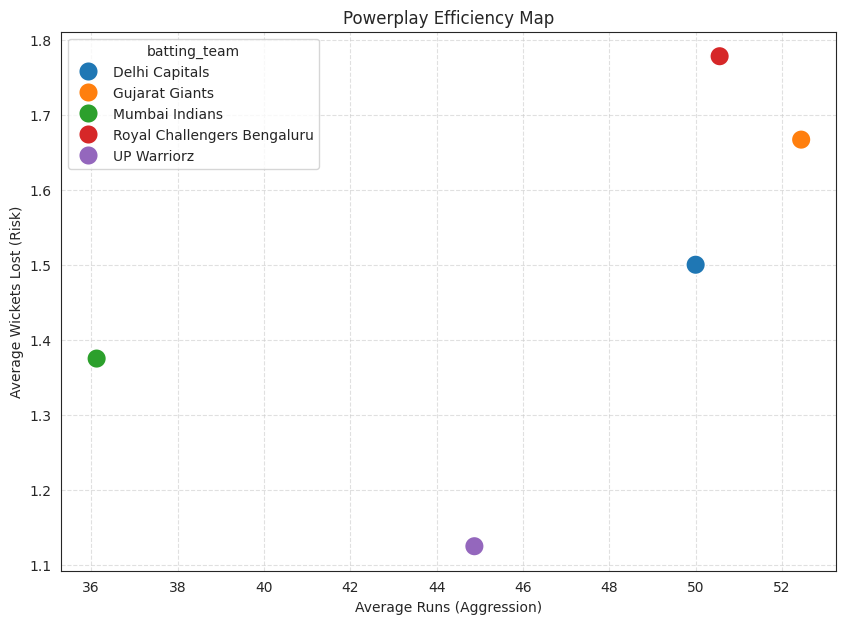

In [41]:
# visualize the team power play efficiency
plt.figure(figsize=(10, 7))
sns.scatterplot(data=team_batting_pp_avg, x='runs_total', y='is_wicket', s=200, hue='batting_team')

plt.title('Powerplay Efficiency Map')
plt.xlabel('Average Runs (Aggression)')
plt.ylabel('Average Wickets Lost (Risk)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(rf'{plot_dir}/powerplay_batting_efficency')
plt.show()

In [45]:
pp_bowling_stats = pp_df.groupby(['match_id','inning','bowling_team']).aggregate(
    {
        'runs_total':'sum',
        'is_wicket':'sum'
    }
).reset_index()

In [48]:
teams_pp_bowling_avg = pp_bowling_stats.groupby('bowling_team').aggregate(
    {
        'runs_total':'mean',
        'is_wicket':'mean'
    }
).reset_index()

In [49]:
teams_pp_bowling_avg

,bowling_team,runs_total,is_wicket
0,Delhi Capitals,46.500000,1.400000
1,Gujarat Giants,47.555556,1.777778
2,Mumbai Indians,49.625000,1.750000
3,Royal Challengers Bengaluru,42.444444,1.666667
4,UP Warriorz,50.375000,0.875000


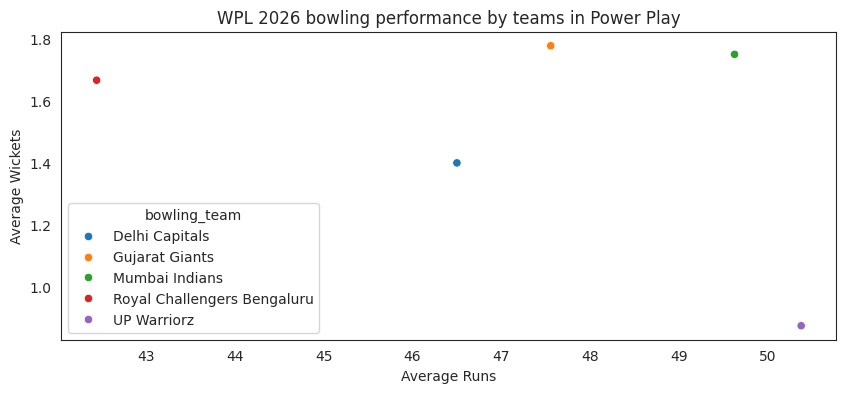

In [57]:
# Visualize bowling stats in power play
plt.figure(figsize=(10,4))
sns.scatterplot(data=teams_pp_bowling_avg,x='runs_total',y='is_wicket',hue='bowling_team')
plt.title("WPL 2026 bowling performance by teams in Power Play")
plt.xlabel("Average Runs")
plt.ylabel("Average Wickets")
plt.savefig(rf'{plot_dir}/powerplay_bowling_efficency')
plt.show()